# **Applied Data Science in Medicine & Psychology - Assignment 8**
## Statistics
---
**Deadline: 04.07.2023, 23:59**
### **General setup and submission**
1. Save an editable copy of this notebook to your Google Drive ``File`` $\rightarrow$ ``Save a copy in Drive`` and remove the automatically appended "Copy of" text. **Do not change the file name**.
2. Work on the assignment in the *copied* version of the notebook. Make sure that you **replace** all parts of the tasks indicated with *YOUR CODE HERE* and **raise NotImplementedError()** (otherwise this causes an error in your implementation) or *YOUR ANSWER HERE* with your solution.
3. If you take a break during the implementation, you can save the current status of your work in your repository following the submission instructions below. When you continue working on the assignment, do this in the version of the notebook that you saved in your Google Drive (access from your Google Colab account) or your repository.
4. After finishing the assignment submit your assignment as follows:
    * Check that everything runs as expected. To do that select in the menubar ``Runtime`` $\rightarrow$ ``Restart and run all``. This will clear all your local variables and runs your notebook from the beginning
    * Save your notebook, click ``File`` $\rightarrow$ ``Save``
    * Click ``File`` $\rightarrow$ ``Save a copy in GitHub``
    * Select ``digikolleg-data-science-psychology/08_statistics-<username>`` from the Repository drop-down menu 
    * Type ``08_statistics.ipynb`` into the File path text box
    * Optionally, you may enter a description into the "Commit message" text box (like: "solved task 1" or "ready for grading")
    * Make sure that the "Include a link to Colaboratory" box is checked
    * Press "Ok"
    * A new tab or window should open up, displaying your submitted notebook within your GitHub repository

Before the assignment deadline, you can re-submit your assignment as often as you would like. This will update the copy of your assignment file in your assignment's repository.

### **Assignment Description**
***General description... TODO***

#### **Assignment goals**
You are going to learn the following things in this assignment:
1. ***TODO***
2. ***TODO***

#### **Assignment point value**
This assignment is worth a total (up to) ***X TODO*** point***(s) TODO***. If your code passes all of the manual and automatic tests you will receive full credit.

### **Tasks**
Make sure that you now work on your *copied* version of this assignment's notebook.

#### 0. Imports and Setup
Please **run** the cell below to import the libraries needed for this assignment.

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# install the BioPsyKit package
!pip install biopsykit
import biopsykit as bp
from scipy import stats


[notice] A new release of pip is available: 23.0 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
# TODO move to the place in assignment where it is needed
data_cortisol = bp.example_data.get_saliva_example() # sampling times [-30, -1, 30, 40, 50, 60, 70]
data_questionnaire = bp.example_data.get_questionnaire_example()
data_stats = bp.example_data.get_stats_example()
data_hr = bp.example_data.get_hr_result_sample()

#### XX. Introductory Task
* mode, mean, median
* multi-modal distribution
* outlier identification and replacement

In [268]:
# run cell to generate artificial distribution
np.random.seed(0) # makes random numbers predictable

data_1 = np.random.normal(loc=17, scale=5, size=(10000)).round(0)
data_2 = np.random.normal(loc=28, scale=3, size=(10000)).round(0)
data = np.concatenate([data_1, data_2])

##### 1.1

In [269]:
### BEGIN SOLUTION
data_mean = np.mean(data)
data_median = np.median(data)
data_mode, _ = stats.mode(data, keepdims=True)
data_mode = int(data_mode)
### END SOLUTION

In [273]:
assert data_mean == 22.4672
assert data_median == 24.0
assert data_mode == 27.0

##### 1.2

In [263]:
### BEGIN SOLUTION
data_zscore = stats.zscore(data)
data_zscore_exclude = np.abs(data_zscore) > 2
data_corrected = data.copy()
data_corrected[data_zscore_exclude] = np.median(data)
### END SOLUTION

In [284]:
assert np.min(data_corrected) == 9 and np.max(data_corrected) == 36
assert np.sum(data_corrected == data_median) > 1000

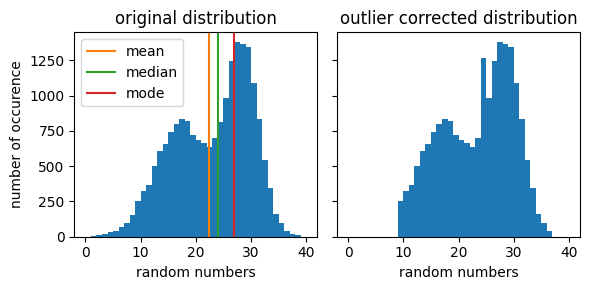

In [266]:
# run cell to visualize both distributions
bins = list(range(0, 41))
fig, axs = plt.subplots(ncols=2, figsize=(6, 3), sharey=True, sharex=True)
_ = axs[0].hist(data, bins=bins)
axs[0].set_title("original distribution")
axs[0].set_xlabel("random numbers")
axs[0].set_ylabel("number of occurence")
for val, key, c in zip([data_mean, data_median, data_mode], ["mean", "median", "mode"], ["tab:orange", "tab:green", "tab:red"]):
    axs[0].axvline(val, color=c, label=key)
axs[0].legend()
_ = axs[1].hist(data_corrected, bins=bins)
axs[1].set_title("outlier corrected distribution")
axs[1].set_xlabel("random numbers")
fig.tight_layout()

#### XX. Questionaire
* Different type of statistical analysis (t-test dependent?)

#### XX. Cortisol Analysis

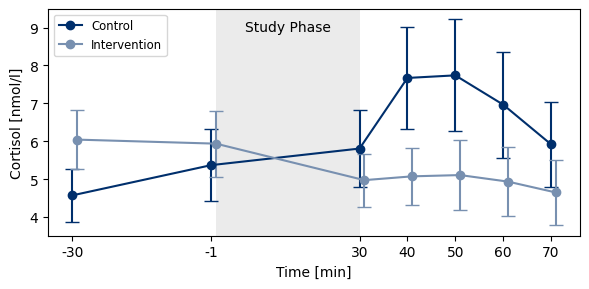

In [32]:
sample_times = [-30, -1, 30, 40, 50, 60, 70]
fig, ax = plt.subplots(figsize=(6, 3))
bp.protocols.plotting.saliva_plot(
    data=data_cortisol, saliva_type="cortisol", sample_times=sample_times, test_times=[0, 30], sample_times_absolute=True,
    test_title="Study Phase", ax=ax,
);

In [30]:
auc = bp.saliva.auc(
    data_cortisol, saliva_type="cortisol", sample_times=sample_times, compute_auc_post=True, remove_s0=True
)
max_inc = bp.saliva.max_increase(data_cortisol, saliva_type="cortisol", remove_s0=True)
slope = bp.saliva.slope(data_cortisol, sample_idx=[1, 4], sample_times=sample_times, saliva_type="cortisol")

cort_features = pd.concat([auc, max_inc, slope], axis=1)
cort_features = bp.saliva.utils.saliva_feature_wide_to_long(cort_features, saliva_type="cortisol")
cort_features.head()

cortisol
condition subject saliva_feature            
Control   Vp03    auc_g           870.418075
                  auc_i           -72.035925
                  auc_i_post      104.057250
                  max_inc           0.956000
                  slope14           0.013971